In [ ]:
import kagglehub
from google.colab import drive
import shutil
import os


drive.mount('/content/drive')


path = kagglehub.dataset_download("himadri07/ciciot2023")

print("Path to dataset files:", path)


drive_destination_path = '/content/drive/MyDrive/kaggle_datasets/ciciot2023'

os.makedirs(drive_destination_path, exist_ok=True)


if os.path.isdir(path):
    for item in os.listdir(path):
        s = os.path.join(path, item)
        d = os.path.join(drive_destination_path, item)
        if os.path.isdir(s):
            shutil.copytree(s, d, dirs_exist_ok=True)
        else:
            shutil.copy2(s, d)
    print(f"All files from '{path}' copied to '{drive_destination_path}' in Google Drive.")
elif os.path.isfile(path):
    shutil.copy2(path, drive_destination_path)
    print(f"File '{path}' copied to '{drive_destination_path}' in Google Drive.")
else:
    print(f"Downloaded path '{path}' is neither a file nor a directory. Nothing copied.")


Mounted at /content/drive


100%|██████████| 477M/477M [00:05<00:00, 94.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/himadri07/ciciot2023/versions/1
All files from '/root/.cache/kagglehub/datasets/himadri07/ciciot2023/versions/1' copied to '/content/drive/MyDrive/kaggle_datasets/ciciot2023' in Google Drive.


In [ ]:
!pip install pennylane --upgrade
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 99.9 MB/s eta 0:00:00


In [ ]:
import pennylane as pl

dev = pl.device("default.qubit",wires=3)

@pl.qnode(dev)
def circuit():
  pl.Hadamard(wires=0)
  pl.CNOT(wires=[0,1])
  pl.Hadamard(wires=2)
  pl.CNOT(wires=[1,2])


  return pl.state() # Returns Complex Ampletudes

print(circuit())


[0.5+0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0.5+0.j]


In [ ]:
import pennylane as pl

dev = pl.device("default.qubit",wires=3)

@pl.qnode(dev)
def circuit():
  pl.Hadamard(wires=0)
  pl.CNOT(wires=[0,1])
  pl.Hadamard(wires=2)
  pl.CNOT(wires=[1,2])


  return pl.expval(pl.PauliZ(0)) # Returns -1 to 1

print(circuit())


0.0


In [ ]:
import pennylane as pl

dev = pl.device("default.qubit",wires=3)

@pl.qnode(dev)
def circuit():
  pl.Hadamard(wires=0)
  pl.CNOT(wires=[0,1])
  pl.Hadamard(wires=2)
  pl.CNOT(wires=[1,2])


  return pl.probs(wires=[0,1,2]) # Returns Probablities

print(circuit())


[0.25 0.25 0.   0.   0.   0.   0.25 0.25]


In [ ]:
import pennylane as pl

dev = pl.device("default.qubit",wires=3)

@pl.set_shots(1000)
@pl.qnode(dev)
def circuit():
  pl.Hadamard(wires=0)
  pl.CNOT(wires=[0,1])
  pl.Hadamard(wires=2)
  pl.CNOT(wires=[1,2])


  return pl.sample() # Returns Sample

print(circuit())

[[1 1 1]
 [0 0 1]
 [1 1 0]
 ...
 [1 1 1]
 [0 0 1]
 [1 1 1]]


In [ ]:
import pennylane as pl

dev = pl.device("default.qubit",wires=3)

@pl.set_shots(1000)
@pl.qnode(dev)
def circuit():
  pl.Hadamard(wires=0)
  pl.CNOT(wires=[0,1])
  pl.Hadamard(wires=2)
  pl.CNOT(wires=[1,2])


  return pl.counts() # Returns counts

cir = circuit()

for i,j in cir.items():
  print(i + "--" + str(j))

000--240
001--275
110--252
111--233


In [ ]:
import pennylane as pl

dev = pl.device("default.qubit",wires=3)

@pl.qnode(dev)
def circuit():
  pl.Hadamard(wires=0)
  pl.CNOT(wires=[0,1])
  pl.Hadamard(wires=2)
  pl.CNOT(wires=[1,2])


  return pl.density_matrix(wires=[0,1]) # Returns Density Matrix

cir = circuit()

print(cir)

[[0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]]


# **Visualization**

In [ ]:
import pennylane as pl

dev = pl.device("default.qubit",wires=3)

@pl.qnode(dev)
def circuit():
  pl.Hadamard(wires=0)
  pl.CNOT(wires=[0,1])
  pl.Hadamard(wires=2)
  pl.CNOT(wires=[1,2])


  return pl.state()

print(pl.draw(circuit)())

0: ──H─╭●────┤  State
1: ────╰X─╭●─┤  State
2: ──H────╰X─┤  State


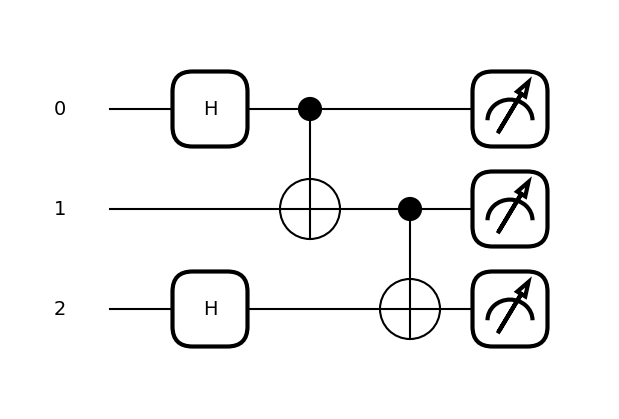

In [ ]:
import pennylane as pl
import matplotlib.pyplot as plt

dev = pl.device("default.qubit",wires=3)

@pl.qnode(dev)
def circuit():
  pl.Hadamard(wires=0)
  pl.CNOT(wires=[0,1])
  pl.Hadamard(wires=2)
  pl.CNOT(wires=[1,2])


  return pl.state()

pl.draw_mpl(circuit,level="device")()
plt.show()

In [ ]:
import seaborn as sns
import pandas as pd

sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [ ]:
df = sns.load_dataset("iris")

In [ ]:
df.head(60)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
df["species"].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [ ]:
import pandas as pd


test_df = pd.concat([
    df.iloc[0:10],
    df.iloc[50:60],
    df.iloc[100:110]
])

print(test_df.head(30))

     sepal_length  sepal_width  petal_length  petal_width     species
0             5.1          3.5           1.4          0.2      setosa
1             4.9          3.0           1.4          0.2      setosa
2             4.7          3.2           1.3          0.2      setosa
3             4.6          3.1           1.5          0.2      setosa
4             5.0          3.6           1.4          0.2      setosa
5             5.4          3.9           1.7          0.4      setosa
6             4.6          3.4           1.4          0.3      setosa
7             5.0          3.4           1.5          0.2      setosa
8             4.4          2.9           1.4          0.2      setosa
9             4.9          3.1           1.5          0.1      setosa
50            7.0          3.2           4.7          1.4  versicolor
51            6.4          3.2           4.5          1.5  versicolor
52            6.9          3.1           4.9          1.5  versicolor
53            5.5   

In [ ]:
train_df = df.drop(test_df.index)
print(train_df.head())

    sepal_length  sepal_width  petal_length  petal_width species
10           5.4          3.7           1.5          0.2  setosa
11           4.8          3.4           1.6          0.2  setosa
12           4.8          3.0           1.4          0.1  setosa
13           4.3          3.0           1.1          0.1  setosa
14           5.8          4.0           1.2          0.2  setosa


In [ ]:
len(train_df)

120

In [ ]:
from sklearn.preprocessing import LabelEncoder ,MinMaxScaler

le = LabelEncoder()
train_df["species"] = le.fit_transform(train_df["species"])
test_df["species"] = le.transform(test_df["species"])


X_train = train_df.drop("species",axis=1)
X_test = test_df.drop("species",axis=1)
y_train = train_df["species"]
y_test = test_df["species"]

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)




In [ ]:
X_train[:5]

array([[0.30555556, 0.70833333, 0.08474576, 0.04166667],
       [0.13888889, 0.58333333, 0.10169492, 0.04166667],
       [0.13888889, 0.41666667, 0.06779661, 0.        ],
       [0.        , 0.41666667, 0.01694915, 0.        ],
       [0.41666667, 0.83333333, 0.03389831, 0.04166667]])

In [ ]:
y_test[:5]

,species
0,0
1,0
2,0
3,0
4,0


In [ ]:
# Angle Encoding
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

dev1 = qml.device("default.qubit", wires=4)
@qml.qnode(dev)
def angle_circuit(x, weights):

    qml.AngleEmbedding(
        x,
        wires=range(4),
        rotation="Y"
    )

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(4)
    )

    return [qml.expval(qml.PauliZ(i))
            for i in range(3)]

In [ ]:
# Amplitude Encoding

import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

dev2 = qml.device("default.qubit", wires=2)

@qml.qnode(dev2)
def amplitude_circuit(x, weights):

    qml.AmplitudeEmbedding(
        x,
        wires=[0,1],
        normalize=True
    )

    qml.StronglyEntanglingLayers(
        weights,
        wires=[0,1]
    )

    return [qml.expval(qml.PauliZ(0)),
            qml.expval(qml.PauliZ(1))]

In [ ]:
# IQP Encoding

import pennylane as qmll
import numpy as np
import matplotlib.pyplot as plt

dev3 = qml.device("default.qubit", wires=4)

@qml.qnode(dev2)
def iqp_circuit(x, weights):

    qml.IQPEmbedding(
        x,
        wires=[0,1],
        normalize=True
    )

    qml.StronglyEntanglingLayers(
        weights,
        wires=[0,1]
    )

    return [qml.expval(qml.PauliZ(0)),
            qml.expval(qml.PauliZ(1))]

In [ ]:
import pennylane as qml
import numpy as np

dev4 = qml.device("default.qubit", wires=4)
@qml.qnode(dev)
def reupload(x, weights):

    qml.AngleEmbedding(
        x,
        wires=range(4)
    )

    qml.StronglyEntanglingLayers(
        weights[0:1],
        wires=range(4)
    )

    qml.AngleEmbedding(
        x,
        wires=range(4)
    )

    qml.StronglyEntanglingLayers(
        weights[1:2],
        wires=range(4)
    )

    qml.AngleEmbedding(
        x,
        wires=range(4)
    )

    qml.StronglyEntanglingLayers(
        weights[2:3],
        wires=range(4)
    )

    return [qml.expval(qml.PauliZ(i))
            for i in range(3)]



